            Chemical_only  Organic_only  Both  None
Date                                               
1992-04-01          92.75          0.73  2.31  4.21
1992-09-01          91.70          1.31  2.13  4.85
1993-04-01          91.49          0.37  3.87  4.27
1993-09-01          90.14          0.79  3.59  5.48
1994-04-01          91.50          0.85  3.86  3.79
<class 'pandas.DataFrame'>
DatetimeIndex: 67 entries, 1992-04-01 to 2025-04-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Chemical_only  67 non-null     float64
 1   Organic_only   67 non-null     float64
 2   Both           67 non-null     float64
 3   None           67 non-null     float64
dtypes: float64(4)
memory usage: 2.6 KB
None


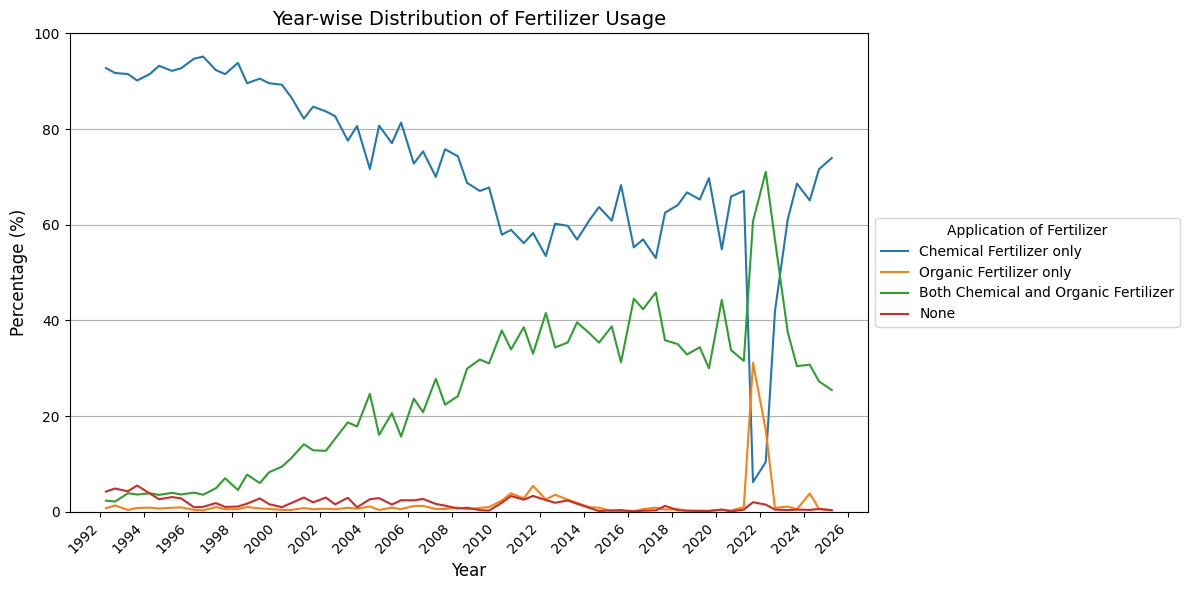

In [25]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error

mpl.rcParams['figure.figsize'] = (10, 8)
mpl.rcParams['axes.grid'] = False

# =========================================================
# LOAD DATA
# =========================================================
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:, :]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df[['Date', 'Chemical_only', 'Organic_only', 'Both', 'None']]
df.set_index('Date', inplace=True)

print(df.head())
print(df.info())

# =========================================================
# PLOT ORIGINAL DATA
# =========================================================
ax = df.plot(figsize=(12, 6))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(0, 100)
plt.xticks(rotation=45)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.legend([
    "Chemical Fertilizer only",
    "Organic Fertilizer only",
    "Both Chemical and Organic Fertilizer",
    "None"
], title="Application of Fertilizer", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Year-wise Distribution of Fertilizer Usage", fontsize=14)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [26]:

# =========================================================
# ADF TEST FUNCTION
# =========================================================
def adf_check(series):
    result = adfuller(series.dropna())
    return result[0], result[1]

# =========================================================
# CHECK ORIGINAL STATIONARITY
# =========================================================
print("\nADF TEST RESULTS (ORIGINAL SERIES)")
diff_count = {}

for column in df.columns:
    adf_stat, p_value = adf_check(df[column])
    print(f"\n{column}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")

    d = 0
    temp_series = df[column].copy()
    while adf_check(temp_series)[1] > 0.05:
        temp_series = temp_series.diff().dropna()
        d += 1
        if d == 3:
            break

    diff_count[column] = d
    print(f"  Differencing Needed : {d}")

# =========================================================
# USE SAME DIFFERENCING ORDER
# =========================================================
max_diff = max(diff_count.values())
print(f"\nMaximum Differencing Order : {max_diff}")



ADF TEST RESULTS (ORIGINAL SERIES)

Chemical_only
  ADF Statistic : -0.8365
  p-value       : 0.8082
  Differencing Needed : 2

Organic_only
  ADF Statistic : -5.3511
  p-value       : 0.0000
  Differencing Needed : 0

Both
  ADF Statistic : -1.4490
  p-value       : 0.5586
  Differencing Needed : 2

None
  ADF Statistic : -3.2007
  p-value       : 0.0199
  Differencing Needed : 0

Maximum Differencing Order : 2


In [27]:

# =========================================================
# DIFFERENCE ALL SERIES
# =========================================================
df_diff = df.copy()
for i in range(max_diff):
    df_diff = df_diff.diff()
df_diff = df_diff.dropna()

# =========================================================
# FINAL STATIONARITY CHECK
# =========================================================
print("\nFINAL STATIONARITY RESULTS")
for column in df_diff.columns:
    adf_stat, p_value = adf_check(df_diff[column])
    print(f"\n{column}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print("  Stationary" if p_value <= 0.05 else "  STILL NOT Stationary")


FINAL STATIONARITY RESULTS

Chemical_only
  ADF Statistic : -6.8817
  p-value       : 0.0000
  Stationary

Organic_only
  ADF Statistic : -5.1534
  p-value       : 0.0000
  Stationary

Both
  ADF Statistic : -5.0812
  p-value       : 0.0000
  Stationary

None
  ADF Statistic : -7.4151
  p-value       : 0.0000
  Stationary


In [28]:

# =========================================================
# TRAIN TEST SPLIT (80 / 20)
# =========================================================
train_size = int(len(df_diff) * 0.8)
train = df_diff.iloc[:train_size]
test  = df_diff.iloc[train_size:]

print(f"\nTrain Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")


Train Shape : (52, 4)
Test Shape  : (13, 4)


In [29]:
# =========================================================
# ADD JITTER TO AVOID SINGULAR COVARIANCE MATRIX
# =========================================================
np.random.seed(42)
train_jittered = train + np.random.normal(0, 1e-6, train.shape)

# =========================================================
# SAFE LAG SELECTION
# =========================================================
n_obs        = len(train_jittered)
n_vars       = train_jittered.shape[1]
safe_maxlags = max(1, int((n_obs - 1) / (n_vars + 1)))
print(f"\nTrain observations    : {n_obs}")
print(f"Number of variables   : {n_vars}")
print(f"Safe max lags allowed : {safe_maxlags}")

selected_lag = 1
for try_lag in range(safe_maxlags, 0, -1):
    try:
        lag_result   = VAR(train_jittered).select_order(maxlags=try_lag)
        selected_lag = lag_result.selected_orders['aic']
        selected_lag = max(1, selected_lag)
        print(f"\nLag Order Selection:")
        print(lag_result.summary())
        print(f"Selected Lag (AIC) : {selected_lag}")
        break
    except Exception as e:
        print(f"  maxlags={try_lag} failed, trying lower...")
        continue


Train observations    : 52
Number of variables   : 4
Safe max lags allowed : 10
  maxlags=10 failed, trying lower...

Lag Order Selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -2.894      -2.730     0.05537      -2.833
1      -5.965      -5.146    0.002578      -5.663
2      -7.235      -5.760   0.0007395      -6.691
3      -7.133      -5.003   0.0008634      -6.347
4      -7.108      -4.323   0.0009820      -6.081
5      -7.749      -4.308   0.0006210      -6.480
6      -8.009      -3.913   0.0006467      -6.499
7      -8.031      -3.280    0.001033      -6.279
8      -9.927      -4.520   0.0003514      -7.933
9     -12.74*     -6.675*  9.518e-05*     -10.50*
-------------------------------------------------
Selected Lag (AIC) : 9


In [30]:
# =========================================================
# FIT VAR MODEL
# =========================================================
var_model  = VAR(train_jittered)
var_result = var_model.fit(selected_lag)




In [31]:

print("\nVAR MODEL SUMMARY")
print(var_result.summary())


VAR MODEL SUMMARY
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 03, Jun, 2026
Time:                     19:06:54
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -6.67530
Nobs:                     43.0000    HQIC:                  -10.5017
Log likelihood:           177.790    FPE:                9.51781e-05
AIC:                     -12.7371    Det(Omega_mle):     7.94421e-06
--------------------------------------------------------------------
Results for equation Chemical_only
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.088827         0.362813            0.245           0.807
L1.Chemical_only       167.959718       109.684881            1.531           0.126
L1.Organic_only      

In [32]:
# =========================================================
# FORECASTING
# =========================================================
forecast_steps  = len(test)
lag_input       = train_jittered.values[-selected_lag:]

forecast_values = var_result.forecast(y=lag_input, steps=forecast_steps)
forecast_df     = pd.DataFrame(
    forecast_values,
    index=test.index,
    columns=test.columns
)

print("\nForecasted Differenced Values")
print(forecast_df.head())


Forecasted Differenced Values
            Chemical_only  Organic_only       Both      None
Date                                                        
2019-04-01     -12.242709     -0.038926  14.011875 -1.706239
2019-09-01      18.400846     -0.341447 -18.457211  0.395222
2020-04-01      -4.573185      1.198350   1.466787  1.892175
2020-09-01      -6.240890     -2.025527   8.264629 -0.002111
2021-04-01       8.048705      0.914880  -4.840897 -4.117295


In [33]:
# =========================================================
# INVERSE DIFFERENCING (generalized for any max_diff)
# =========================================================
forecast_restored = forecast_df.copy()

for level in range(max_diff):
    ref = df.copy()
    for _ in range(max_diff - 1 - level):
        ref = ref.diff().dropna()
    last_val = ref.iloc[: train_size + max_diff - 1 - level].iloc[-1]
    forecast_restored = forecast_restored.cumsum() + last_val


In [34]:
# =========================================================
# CLIP & NORMALIZE
# =========================================================
forecast_restored = forecast_restored.clip(lower=0, upper=100)
forecast_restored = forecast_restored.div(
    forecast_restored.sum(axis=1), axis=0
) * 100

print("\nForecasts After Normalization")
print(forecast_restored.head())



Forecasts After Normalization
            Chemical_only  Organic_only       Both  None
Date                                                    
2019-04-01      52.586387      0.030886  47.382727   0.0
2019-09-01      60.056682      0.000000  39.943318   0.0
2020-04-01      64.759855      0.000000  35.240145   0.0
2020-09-01      62.119066      0.000000  37.880934   0.0
2021-04-01      65.258292      0.000000  34.741708   0.0


In [35]:
# =========================================================
# ACTUAL TEST VALUES
# =========================================================
actual_original  = df.iloc[train_size + max_diff:]
actual_original  = actual_original.loc[forecast_restored.index]

In [36]:
# =========================================================
# 1. FORECASTING ACCURACY — MAE, RMSE, NRMSE
# =========================================================
print("\n" + "="*60)
print("1. FORECASTING ACCURACY")
print("="*60)

evaluation_results = []

for column in actual_original.columns:
    actual    = actual_original[column]
    predicted = forecast_restored[column]

    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # NRMSE — normalized by range
    value_range = actual.max() - actual.min()
    nrmse = (rmse / value_range * 100) if value_range != 0 else np.nan

    # MAPE — skip zeros
    nonzero = actual != 0
    mape = np.mean(np.abs(
        (actual[nonzero] - predicted[nonzero]) / actual[nonzero]
    )) * 100 if nonzero.sum() > 0 else np.nan

    evaluation_results.append([column, mae, rmse, nrmse, mape])

    print(f"\n{column}")
    print(f"  MAE   : {mae:.4f}  (percentage points)")
    print(f"  RMSE  : {rmse:.4f}  (percentage points)")
    print(f"  NRMSE : {nrmse:.2f}%")
    print(f"  MAPE  : {mape:.2f}%" if not np.isnan(mape) else "  MAPE  : N/A")

evaluation_df = pd.DataFrame(
    evaluation_results,
    columns=['Variable', 'MAE', 'RMSE', 'NRMSE(%)', 'MAPE(%)']
)
print("\nAccuracy Summary Table:")
print(evaluation_df.to_string(index=False))


1. FORECASTING ACCURACY

Chemical_only
  MAE   : 15.4470  (percentage points)
  RMSE  : 21.9458  (percentage points)
  NRMSE : 32.39%
  MAPE  : 115.34%

Organic_only
  MAE   : 4.3468  (percentage points)
  RMSE  : 9.9087  (percentage points)
  NRMSE : 31.97%
  MAPE  : 92.25%

Both
  MAE   : 11.3080  (percentage points)
  RMSE  : 13.4178  (percentage points)
  NRMSE : 29.42%
  MAPE  : 27.88%

None
  MAE   : 0.5569  (percentage points)
  RMSE  : 0.7683  (percentage points)
  NRMSE : 39.81%
  MAPE  : 100.00%

Accuracy Summary Table:
     Variable       MAE      RMSE  NRMSE(%)    MAPE(%)
Chemical_only 15.446974 21.945830 32.392369 115.337714
 Organic_only  4.346837  9.908680 31.973798  92.245003
         Both 11.308038 13.417787 29.418519  27.877796
         None  0.556923  0.768305 39.808540 100.000000


In [42]:
print(actual_original.columns)

Index(['Chemical_only', 'Organic_only', 'Both', 'None'], dtype='str')


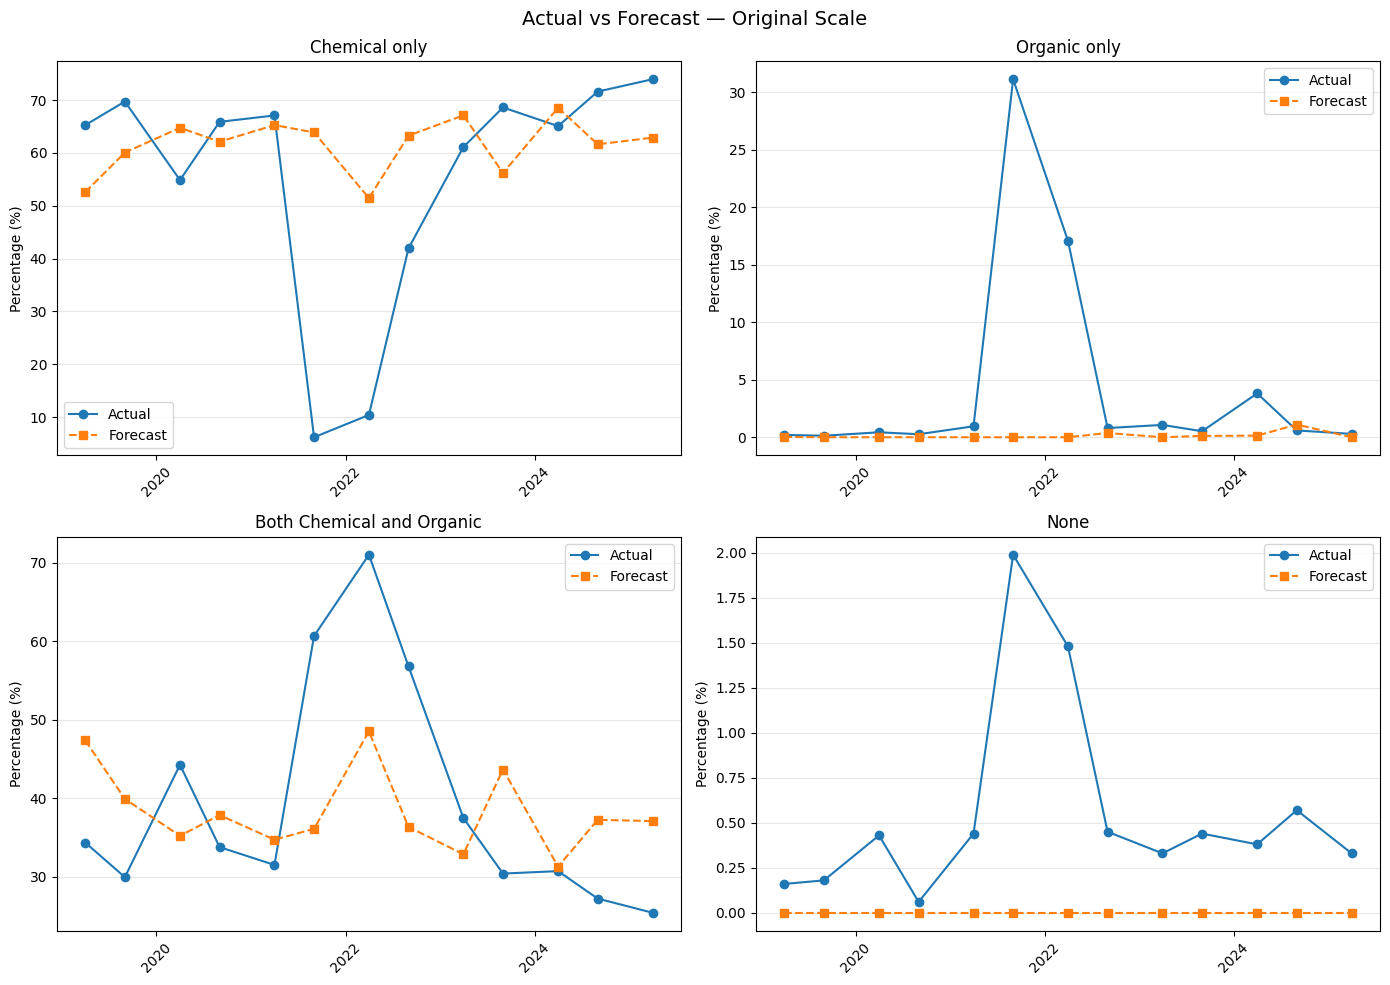

In [43]:
title_map = {
    'Chemical_only': 'Chemical only',
    'Organic_only': 'Organic only',
    'Both': 'Both Chemical and Organic',
    'None': 'None'
}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, column in enumerate(actual_original.columns):

    axes[i].plot(actual_original.index,
                 actual_original[column],
                 marker='o',
                 label='Actual')

    axes[i].plot(forecast_restored.index,
                 forecast_restored[column],
                 marker='s',
                 linestyle='--',
                 label='Forecast')

    axes[i].set_title(
        title_map.get(column, column),
        fontsize=12
    )

    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle("Actual vs Forecast — Original Scale", fontsize=14)
plt.tight_layout()
plt.show()


2. GRANGER CAUSALITY ANALYSIS
Using lag = 9 (same as VAR model)

Organic_only         → Chemical_only        | F=1.7560  p=0.1304  ns
Both                 → Chemical_only        | F=1.5759  p=0.1790  ns
None                 → Chemical_only        | F=1.3936  p=0.2455  ns
Chemical_only        → Organic_only         | F=0.4216  p=0.9106  ns
Both                 → Organic_only         | F=0.6371  p=0.7546  ns
None                 → Organic_only         | F=0.5228  p=0.8436  ns
Chemical_only        → Both                 | F=1.5495  p=0.1874  ns
Organic_only         → Both                 | F=1.3238  p=0.2764  ns
None                 → Both                 | F=1.3690  p=0.2560  ns
Chemical_only        → None                 | F=0.7099  p=0.6945  ns
Organic_only         → None                 | F=0.6701  p=0.7274  ns
Both                 → None                 | F=0.6718  p=0.7260  ns

Granger Causality Summary:
        Cause        Effect  F-statistic  p-value Significance
 Organic_only C

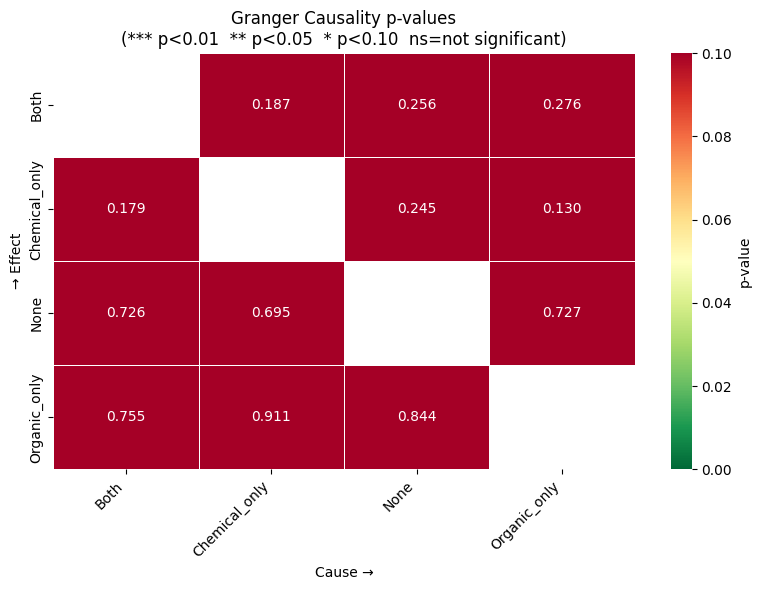

In [38]:
# =========================================================
# 2. GRANGER CAUSALITY — FULL MATRIX
# =========================================================
print("\n" + "="*60)
print("2. GRANGER CAUSALITY ANALYSIS")
print("="*60)
print(f"Using lag = {selected_lag} (same as VAR model)\n")

columns      = train_jittered.columns.tolist()
gc_results   = []

for caused in columns:
    for cause in columns:
        if cause == caused:
            continue
        try:
            test_data = train_jittered[[caused, cause]]
            gc_test   = grangercausalitytests(
                test_data,
                maxlag=selected_lag,
                verbose=False
            )
            p_value = gc_test[selected_lag][0]['ssr_ftest'][1]
            f_stat  = gc_test[selected_lag][0]['ssr_ftest'][0]

            if p_value <= 0.01:
                sig = "***"
            elif p_value <= 0.05:
                sig = "**"
            elif p_value <= 0.10:
                sig = "*"
            else:
                sig = "ns"

            gc_results.append({
                'Cause':        cause,
                'Effect':       caused,
                'F-statistic':  round(f_stat, 4),
                'p-value':      round(p_value, 4),
                'Significance': sig
            })

            print(f"{cause:20s} → {caused:20s} | "
                  f"F={f_stat:.4f}  p={p_value:.4f}  {sig}")

        except Exception as e:
            print(f"  Skipped {cause} → {caused} : {e}")

gc_df = pd.DataFrame(gc_results)

print("\nGranger Causality Summary:")
print(gc_df.to_string(index=False))

# --- Heatmap ---
pivot_p = gc_df.pivot(index='Effect', columns='Cause', values='p-value')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_p,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=0.10,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'p-value'}
)
ax.set_title(
    "Granger Causality p-values\n"
    "(*** p<0.01  ** p<0.05  * p<0.10  ns=not significant)",
    fontsize=12
)
ax.set_xlabel("Cause →")
ax.set_ylabel("→ Effect")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


3. IMPULSE RESPONSE FUNCTIONS (IRF)
IRF plot: shows how a shock in one variable
affects all other variables over time.



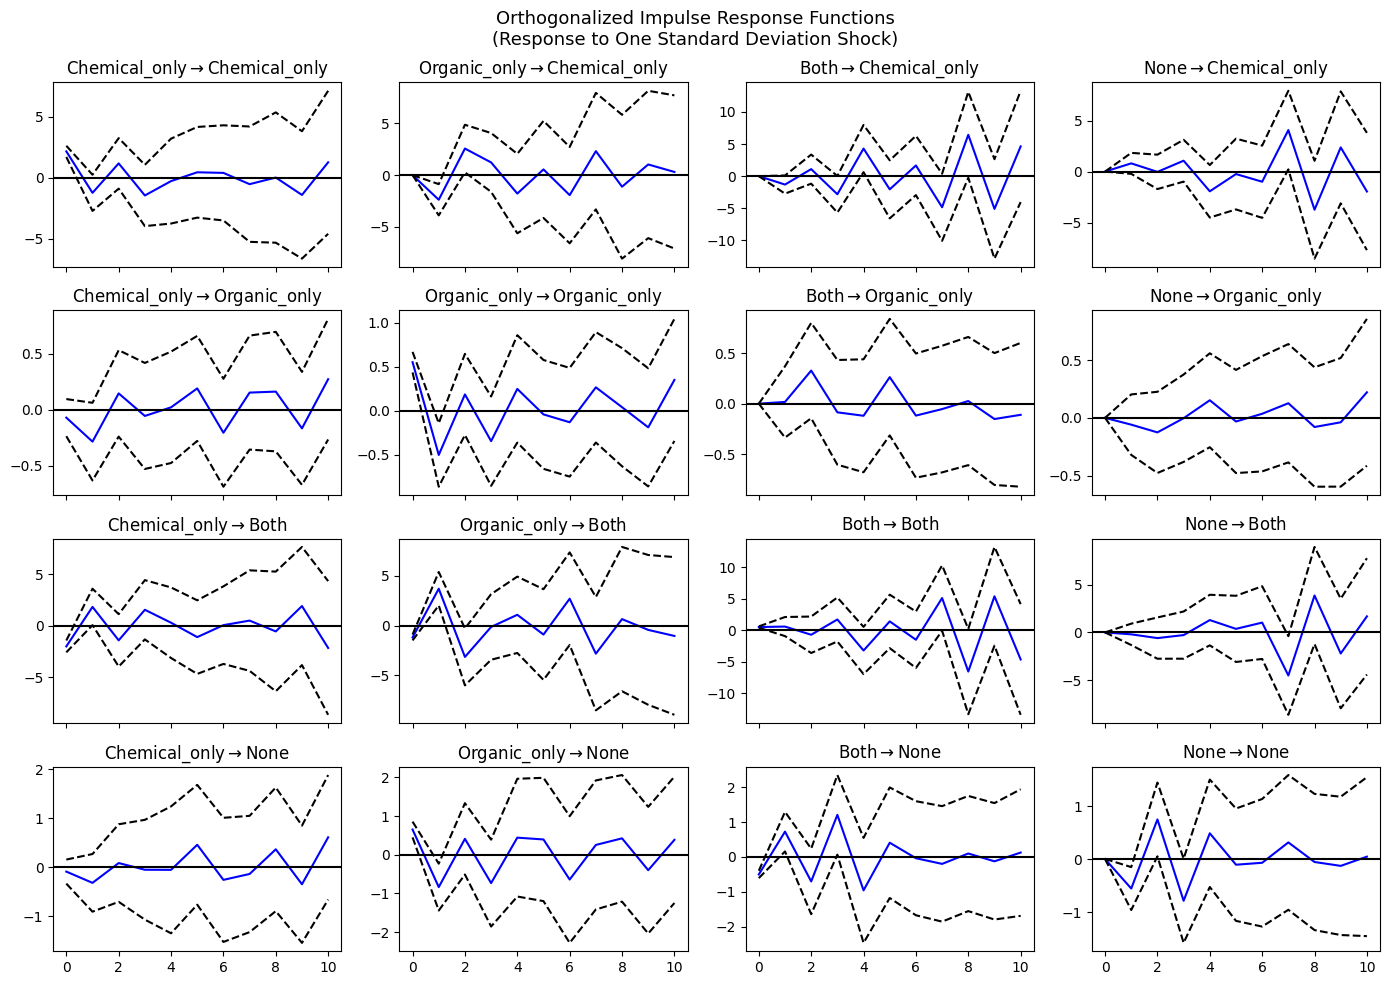

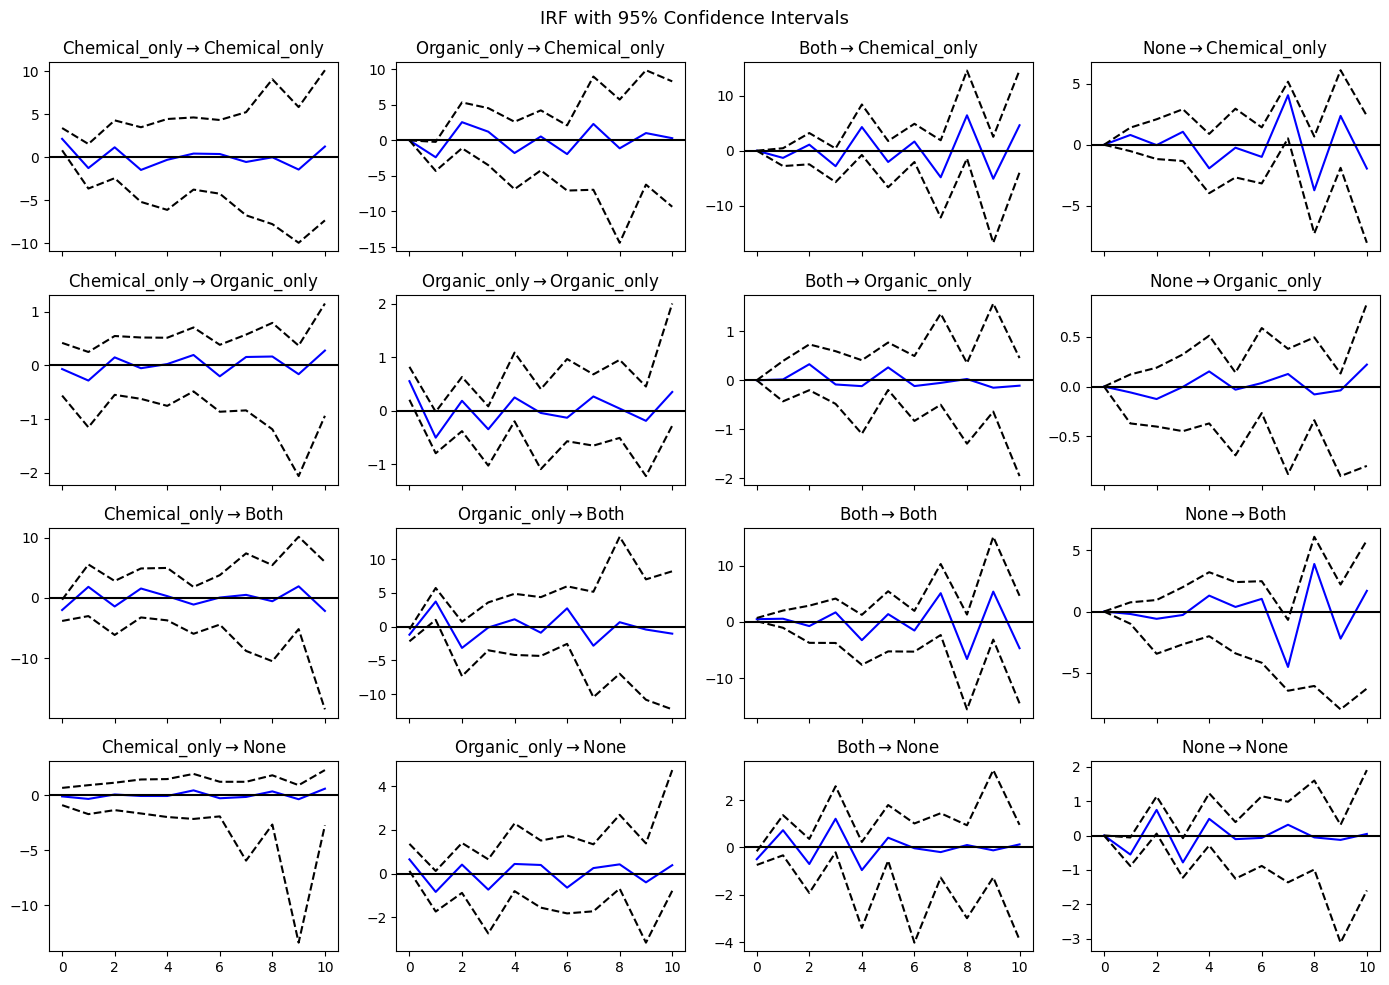

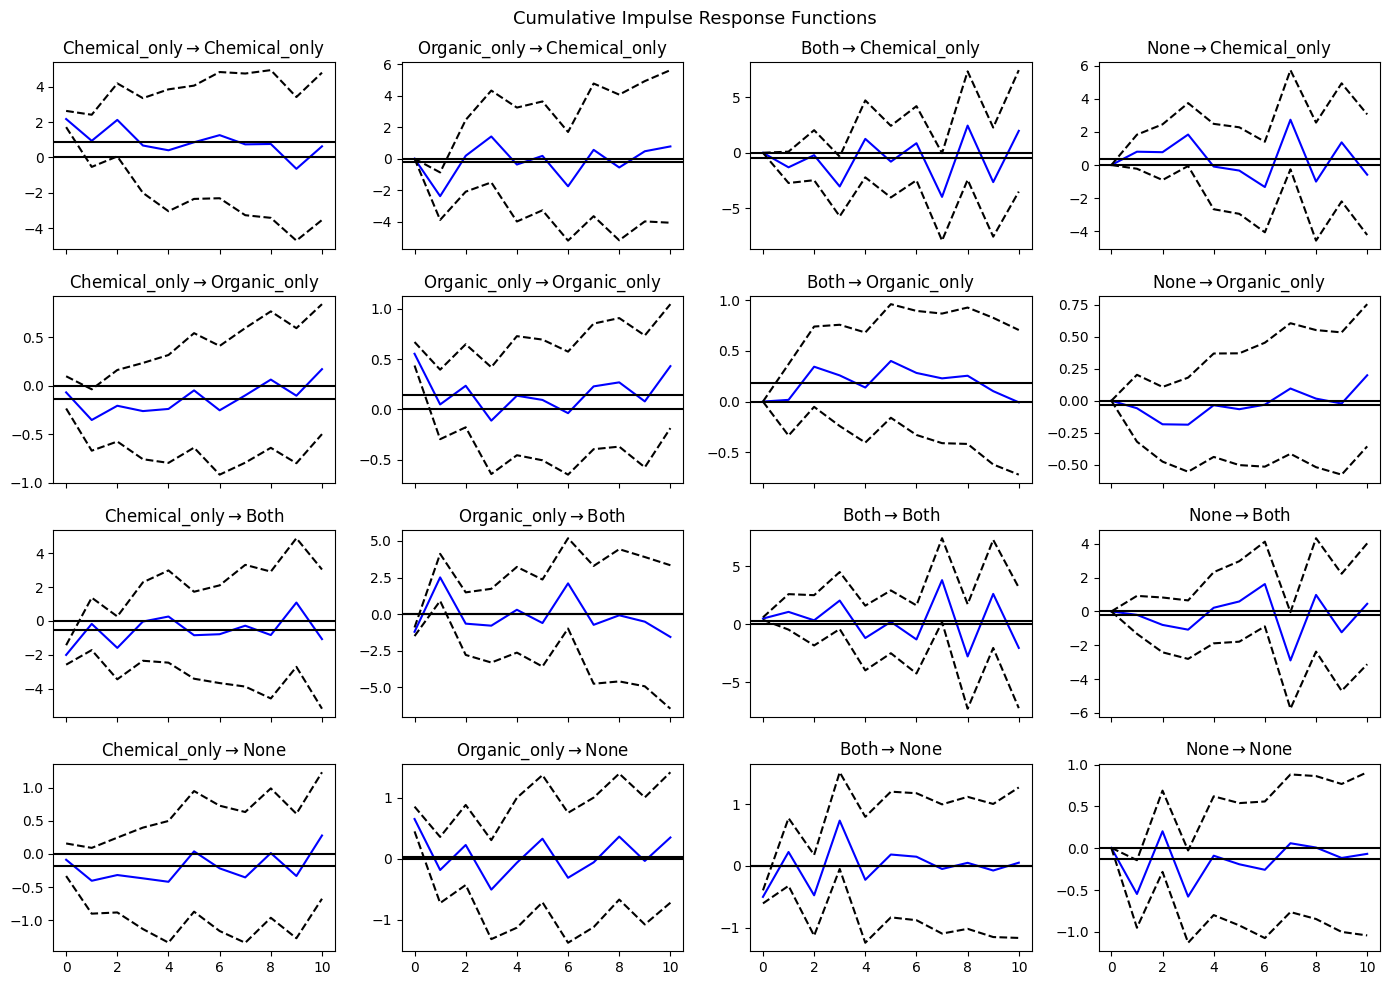

In [39]:

# =========================================================
# 3. IMPULSE RESPONSE FUNCTIONS (IRF)
# =========================================================
print("\n" + "="*60)
print("3. IMPULSE RESPONSE FUNCTIONS (IRF)")
print("="*60)

irf_periods = 10

irf = var_result.irf(periods=irf_periods)

print("IRF plot: shows how a shock in one variable")
print("affects all other variables over time.\n")

# Plot IRF
irf.plot(
    orth=True,
    figsize=(14, 10)
)
plt.suptitle(
    "Orthogonalized Impulse Response Functions\n"
    "(Response to One Standard Deviation Shock)",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Plot IRF with confidence intervals
irf.plot(
    orth=True,
    stderr_type='mc',
    repl=100,
    figsize=(14, 10)
)
plt.suptitle(
    "IRF with 95% Confidence Intervals",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Cumulative IRF
irf.plot_cum_effects(
    orth=True,
    figsize=(14, 10)
)
plt.suptitle(
    "Cumulative Impulse Response Functions",
    fontsize=13
)
plt.tight_layout()
plt.show()


4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
FEVD: shows what % of each variable's forecast
error variance is explained by each variable.

FEVD Shape: (4, 10, 4)

--------------------------------------------------
FEVD for Chemical_only
--------------------------------------------------
        Chemical_only  Organic_only   Both   None
Period                                           
1              100.00          0.00   0.00   0.00
2               43.70         39.66  12.09   4.56
3               32.58         52.17  12.48   2.78
4               26.92         37.96  30.17   4.95
5               15.90         27.40  47.70   8.99
6               15.06         25.87  50.63   8.43
7               13.73         28.23  49.14   8.90
8                8.72         21.91  50.01  19.36
9                5.91         15.57  57.44  21.07
10               5.88         13.51  60.34  20.28

--------------------------------------------------
FEVD for Organic_only
----------------------------------

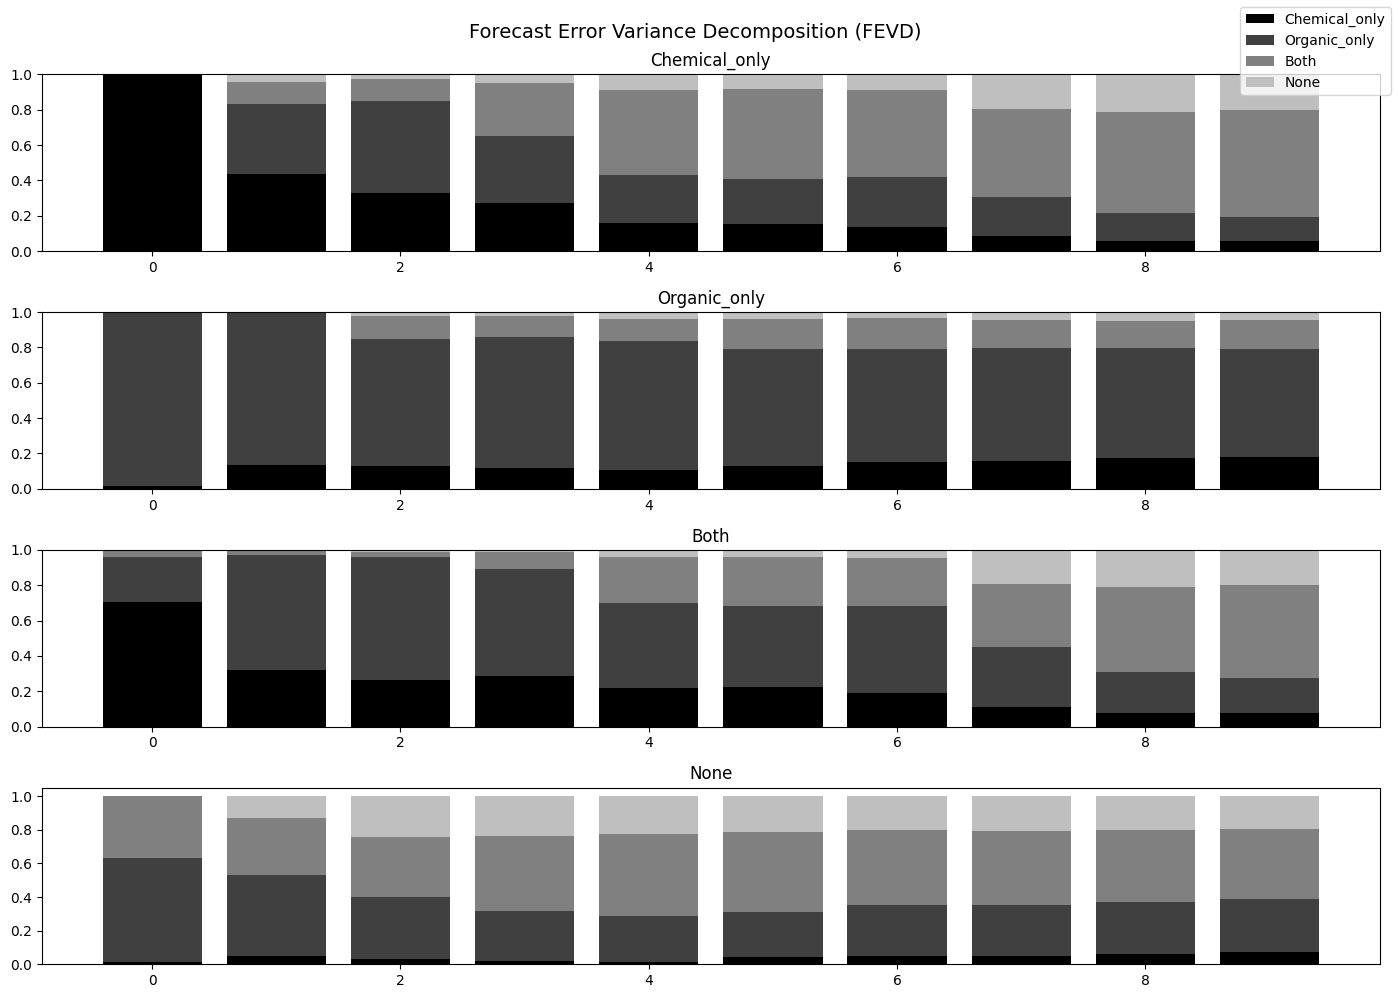

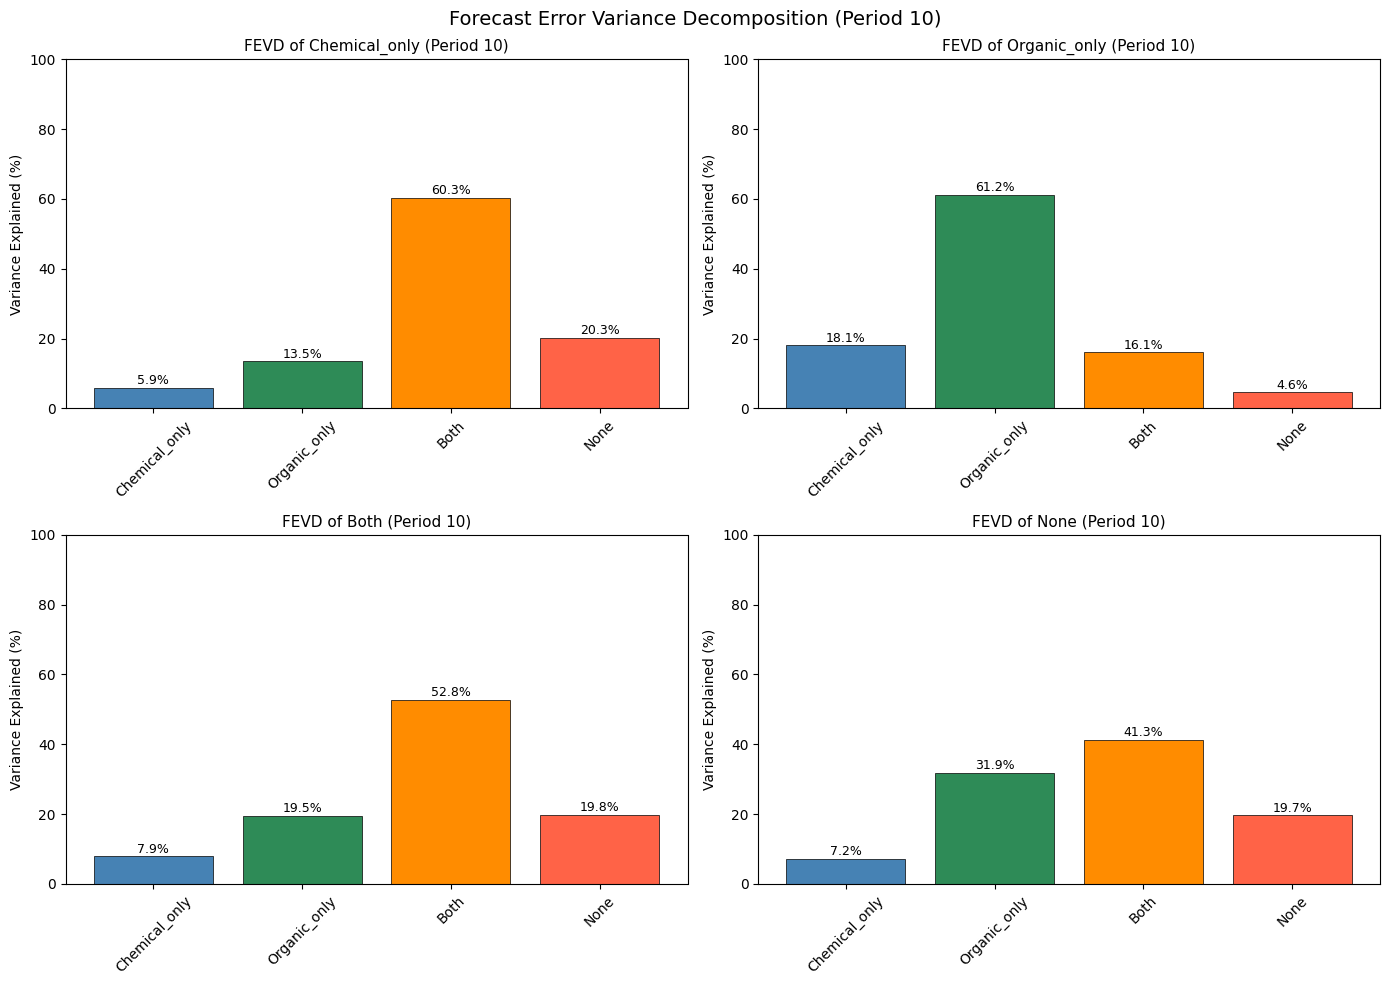

In [41]:
# =========================================================
# 4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
# =========================================================

print("\n" + "="*60)
print("4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)")
print("="*60)

fevd_periods = 10

# Compute FEVD
fevd = var_result.fevd(fevd_periods)

print("FEVD: shows what % of each variable's forecast")
print("error variance is explained by each variable.\n")

# Extract FEVD array
fevd_results = fevd.decomp

print("FEVD Shape:", fevd_results.shape)

# =========================================================
# FEVD TABLES
# =========================================================

for i, col in enumerate(df.columns):

    print(f"\n{'-'*50}")
    print(f"FEVD for {col}")
    print(f"{'-'*50}")

    fevd_df = pd.DataFrame(
        fevd_results[i, :, :],   # Variable i, all periods, all contributors
        columns=df.columns
    )

    fevd_df.index = np.arange(1, len(fevd_df) + 1)
    fevd_df.index.name = "Period"

    print((fevd_df * 100).round(2).to_string())

# =========================================================
# BUILT-IN FEVD PLOT
# =========================================================

fevd.plot(figsize=(14, 10))
plt.suptitle(
    "Forecast Error Variance Decomposition (FEVD)",
    fontsize=14
)
plt.tight_layout()
plt.show()

# =========================================================
# CUSTOM FEVD BAR CHART AT FINAL PERIOD
# =========================================================

n_vars = len(df.columns)

fig, axes = plt.subplots(
    nrows=int(np.ceil(n_vars / 2)),
    ncols=2,
    figsize=(14, 10)
)

axes = np.array(axes).flatten()

colors_fevd = [
    'steelblue',
    'seagreen',
    'darkorange',
    'tomato',
    'purple',
    'gold'
]

# Use last available FEVD period
period_to_plot = min(fevd_periods, fevd_results.shape[1])

for i, col in enumerate(df.columns):

    # FEVD values at selected period
    fevd_at_period = fevd_results[i, period_to_plot - 1, :] * 100

    axes[i].bar(
        df.columns,
        fevd_at_period,
        color=colors_fevd[:n_vars],
        edgecolor='black',
        linewidth=0.5
    )

    axes[i].set_title(
        f"FEVD of {col} (Period {period_to_plot})",
        fontsize=11
    )

    axes[i].set_ylabel("Variance Explained (%)")
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=45)

    for j, val in enumerate(fevd_at_period):
        axes[i].text(
            j,
            val + 1,
            f"{val:.1f}%",
            ha='center',
            fontsize=9
        )

# Remove unused subplots
for k in range(n_vars, len(axes)):
    fig.delaxes(axes[k])

plt.suptitle(
    f"Forecast Error Variance Decomposition (Period {period_to_plot})",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:

# # =========================================================
# # SAVE ALL RESULTS
# # =========================================================
# forecast_restored.to_excel("VAR_Forecasts.xlsx")

# with pd.ExcelWriter("VAR_Full_Analysis.xlsx") as writer:
#     evaluation_df.to_excel(writer, sheet_name='Accuracy',          index=False)
#     gc_df.to_excel(        writer, sheet_name='Granger_Causality', index=False)

#     for i, col in enumerate(df.columns):
#         fevd_df = pd.DataFrame(
#             fevd_results[:, i, :],
#             columns=df.columns
#         )
#         fevd_df.index = fevd_df.index + 1
#         fevd_df.index.name = 'Period'
#         fevd_df.to_excel(writer, sheet_name=f'FEVD_{col[:10]}')

# print("\nAll results saved to VAR_Full_Analysis.xlsx")
# print("Forecasts saved to VAR_Forecasts.xlsx")
# print("\nDone.")